In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

## Load the Mall Customers dataset

In [3]:
# Load the Mall Customers dataset
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Selection and Preprocessing

In [4]:
# Drop CustomerID as it is not useful for clustering
df = df.drop(['CustomerID'], axis=1)

# One-hot encoding for Gender column
df = pd.get_dummies(df, columns=['Gender'])

# Separate features
X = df.copy()

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Scale the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

print(X_scaled.head())

        Age  Annual Income (k$)  Spending Score (1-100)  Gender_Female  \
0 -1.424569           -1.738999               -0.434801      -1.128152   
1 -1.281035           -1.738999                1.195704      -1.128152   
2 -1.352802           -1.700830               -1.715913       0.886405   
3 -1.137502           -1.700830                1.040418       0.886405   
4 -0.563369           -1.662660               -0.395980       0.886405   

   Gender_Male  
0     1.128152  
1     1.128152  
2    -0.886405  
3    -0.886405  
4    -0.886405  


## Visualise the original data on a scatter plot

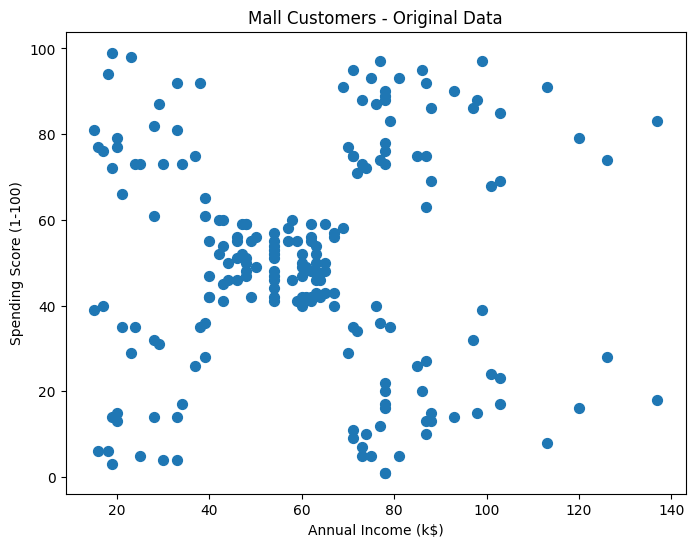

In [5]:
# Visualize the data before clustering
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            s=50)
plt.title('Mall Customers - Original Data')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

## Elbow Method and Silhouette Score

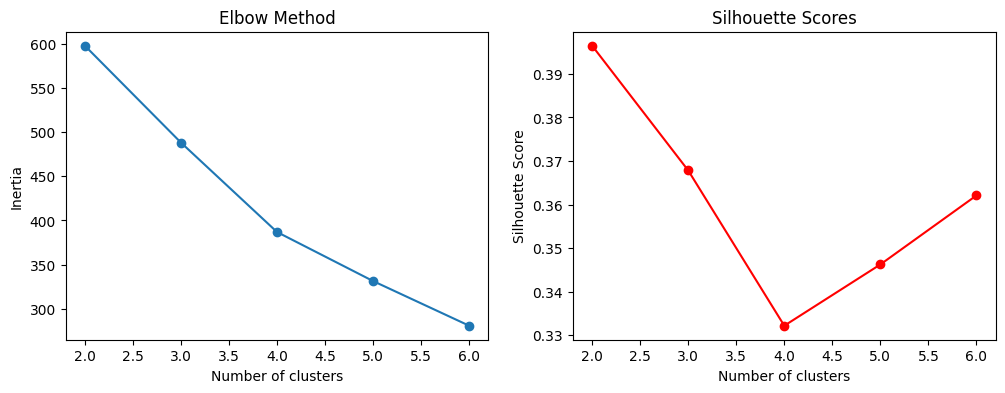

In [6]:
# Determine the optimal number of clusters
# using Elbow Method and Silhouette Score
inertia_list = []
silhouette_list = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow Method and Silhouette Scores
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 7), inertia_list, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(range(2, 7), silhouette_list, marker='o', color='red')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")

plt.show()

## Apply KMeans Clustering

In [7]:
# Apply KMeans clustering with optimal clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

print("Inertia:", kmeans.inertia_)

Inertia: 331.26499941323004


## Apply Agglomerative Clustering

In [8]:
# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=5)
labels_agg = agg.fit_predict(X_scaled)

## Silhouette Scores for both models

In [9]:
# Calculate and print Silhouette Scores
sil_score_kmeans = silhouette_score(X_scaled, labels_kmeans)
sil_score_agg = silhouette_score(X_scaled, labels_agg)

print("KMeans Silhouette Score:", sil_score_kmeans)
print("Hierarchical Silhouette Score:", sil_score_agg)

KMeans Silhouette Score: 0.3462618438920992
Hierarchical Silhouette Score: 0.33339195354757967


## Compare actual and predicted clusters visually

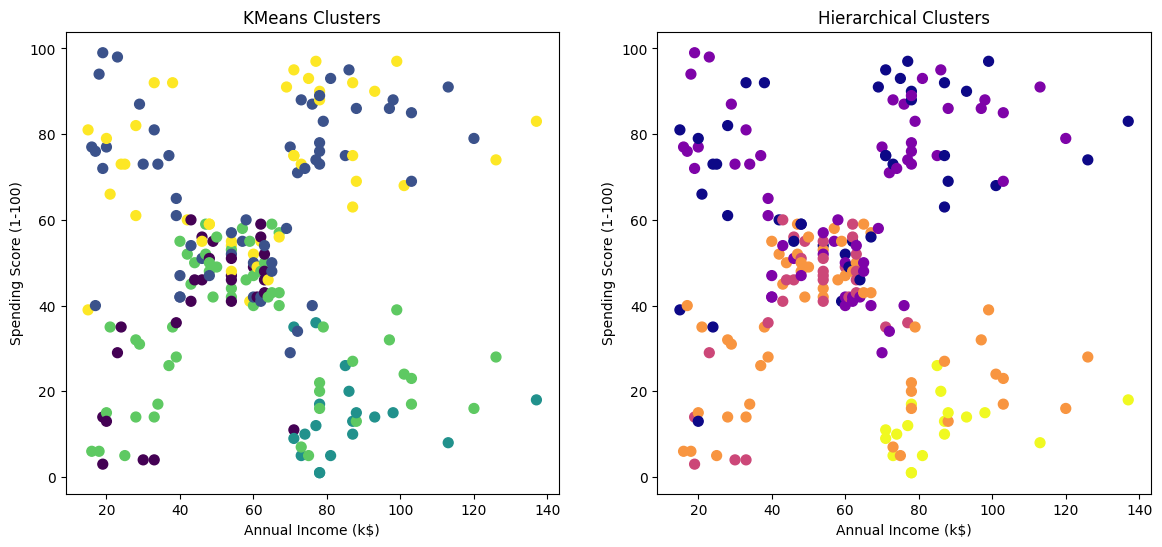

In [10]:
# Add predicted labels to dataframe
df['KMeans_Cluster'] = labels_kmeans
df['Hierarchical_Cluster'] = labels_agg

# Two plots showing KMeans and Hierarchical clustering
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KMeans Clusters
axes[0].scatter(df['Annual Income (k$)'],
                df['Spending Score (1-100)'],
                c=df['KMeans_Cluster'],
                cmap='viridis', s=50)
axes[0].set_title('KMeans Clusters')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')

# Hierarchical Clusters
axes[1].scatter(df['Annual Income (k$)'],
                df['Spending Score (1-100)'],
                c=df['Hierarchical_Cluster'],
                cmap='plasma', s=50)
axes[1].set_title('Hierarchical Clusters')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')

plt.show()

## Dimensionality Reduction using PCA

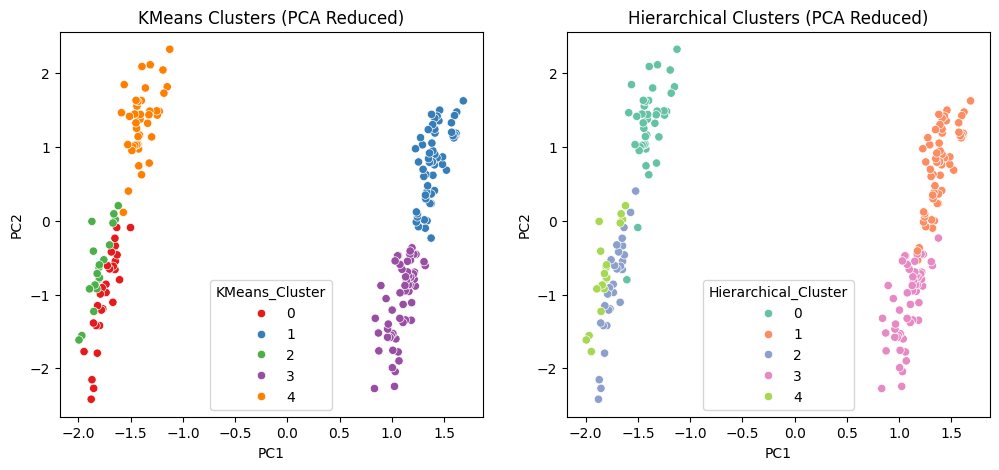

In [11]:
# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['KMeans_Cluster'] = labels_kmeans
df_pca['Hierarchical_Cluster'] = labels_agg

# Visualize the clusters in 2D PCA space
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2',
                hue='KMeans_Cluster',
                data=df_pca, palette='Set1')
plt.title("KMeans Clusters (PCA Reduced)")

plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2',
                hue='Hierarchical_Cluster',
                data=df_pca, palette='Set2')
plt.title("Hierarchical Clusters (PCA Reduced)")

plt.show()

## Model Evaluation Summary

In [12]:
print("KMeans Silhouette Score:", sil_score_kmeans)
print("Hierarchical Silhouette Score:", sil_score_agg)

KMeans Silhouette Score: 0.3462618438920992
Hierarchical Silhouette Score: 0.33339195354757967
